# Machine Learning — Match Outcome Prediction

The goal of this phase is to build a machine learning model that predicts the outcome of a football match.

The target variable is:

- H → Home win
- D → Draw
- A → Away win

This makes the problem a multiclass classification problem.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

## 1. Load the Feature-Engineered Dataset

In [2]:
df = pd.read_csv(
    "../data/processed/PremierLeague25_26_features.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,HomeTeam,AwayTeam,HomeMatchesBefore,HomeGoalsForBefore,HomeGoalsAgainstBefore,HomePointsBefore,AwayMatchesBefore,AwayGoalsForBefore,AwayGoalsAgainstBefore,...,FTR,HomeAvgGoalsFor,HomeAvgGoalsAgainst,AwayAvgGoalsFor,AwayAvgGoalsAgainst,HomePointsPerMatch,AwayPointsPerMatch,AttackDifference,DefenseDifference,PointsDifference
0,2025-08-15,Liverpool,Bournemouth,0,0,0,0,0,0,0,...,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-08-16,Aston Villa,Newcastle,0,0,0,0,0,0,0,...,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-08-16,Brighton,Fulham,0,0,0,0,0,0,0,...,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-08-16,Sunderland,West Ham,0,0,0,0,0,0,0,...,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-08-16,Tottenham,Burnley,0,0,0,0,0,0,0,...,H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 380
Columns: 21


## 2. Define Features and Target

The target is `FTR`.

The model will use historical team-performance features created in the previous notebook.

We deliberately do not use current-match statistics such as goals, shots, corners or cards because they would contain information that is unavailable before the match.

In [4]:
ml_features = [
    "HomeAvgGoalsFor",
    "HomeAvgGoalsAgainst",
    "AwayAvgGoalsFor",
    "AwayAvgGoalsAgainst",
    "HomePointsPerMatch",
    "AwayPointsPerMatch",
    "AttackDifference",
    "DefenseDifference",
    "PointsDifference"
]

X = df[ml_features]

y = df["FTR"]

In [5]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

Feature matrix shape: (380, 9)
Target shape: (380,)

Features:
['HomeAvgGoalsFor', 'HomeAvgGoalsAgainst', 'AwayAvgGoalsFor', 'AwayAvgGoalsAgainst', 'HomePointsPerMatch', 'AwayPointsPerMatch', 'AttackDifference', 'DefenseDifference', 'PointsDifference']

Target classes:
<StringArray>
['H', 'D', 'A']
Length: 3, dtype: str


## 3. Understand the Target Distribution

Before training a model, we need to understand how balanced the target classes are.

A football dataset may contain different numbers of home wins, draws and away wins.

This matters because accuracy can be misleading when classes are imbalanced.

In [6]:
class_counts = y.value_counts()

class_counts

FTR
H    162
A    114
D    104
Name: count, dtype: int64

In [7]:
class_percentages = (
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_percentages

FTR
H    42.63
A    30.00
D    27.37
Name: proportion, dtype: float64

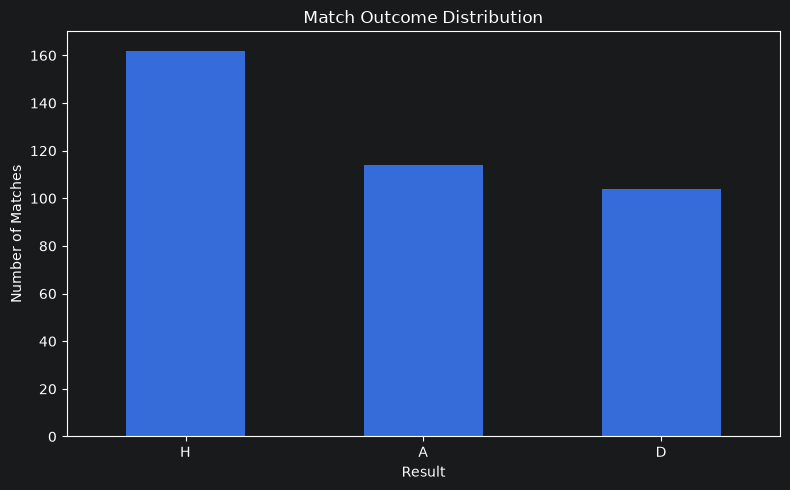

In [8]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Match Outcome Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Why This Is Classification

The target `FTR` contains discrete categories:

- H
- D
- A

We are not predicting a continuous numerical value such as the number of goals.

Therefore, the problem is:

**Multiclass Classification**

The model must choose one of three classes for each match.

## 5. Why We Use a Chronological Train/Test Split

Football matches are time-dependent.

A model should not train on future matches and then be evaluated on earlier matches.

Therefore, instead of randomly shuffling the dataset, we preserve chronological order.

Earlier matches → Training data

Later matches → Testing data

This better represents the real-world scenario of predicting future matches using historical information.

In [9]:
df = df.sort_values("Date").reset_index(drop=True)

In [10]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Training matches:", len(train_df))
print("Testing matches:", len(test_df))

Training matches: 304
Testing matches: 76


In [11]:
X_train = train_df[ml_features]
X_test = test_df[ml_features]

y_train = train_df["FTR"]
y_test = test_df["FTR"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (304, 9)
X_test: (76, 9)
y_train: (304,)
y_test: (76,)


## 6. Baseline Model

Before using machine learning, we need a simple baseline.

A baseline gives us a reference point.

We will use `DummyClassifier` with the `most_frequent` strategy.

It always predicts the most common class in the training data.

A useful ML model should perform better than this baseline.

In [12]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train,
    y_train
)

DummyClassifier(strategy='most_frequent')

In [13]:
baseline_predictions = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline accuracy:",
    round(baseline_accuracy, 4)
)

Baseline accuracy: 0.4737


## 7. First Machine Learning Model — Logistic Regression

Logistic Regression is a useful baseline classification algorithm.

Despite its name, Logistic Regression is commonly used for classification.

It estimates the probability of each class and selects the class with the highest probability.

We start with it because it is:

- relatively simple
- interpretable
- fast to train
- a good baseline for classification

In [14]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


LogisticRegression(max_iter=1000)

In [15]:
logistic_predictions = logistic_model.predict(X_test)

In [16]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression accuracy:",
    round(logistic_accuracy, 4)
)

Logistic Regression accuracy: 0.5526


## 8. Classification Report

Accuracy gives the overall percentage of correct predictions.

However, it does not tell us how well the model performs for each class.

The classification report provides:

- Precision
- Recall
- F1-score
- Support

for each class.

In [17]:
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

              precision    recall  f1-score   support

           A       0.50      0.30      0.38        20
           D       0.00      0.00      0.00        20
           H       0.56      1.00      0.72        36

    accuracy                           0.55        76
   macro avg       0.35      0.43      0.36        76
weighted avg       0.40      0.55      0.44        76



C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

### Metric meanings

**Precision**

Of the matches predicted as a particular class, how many were actually that class?

**Recall**

Of the actual matches belonging to a class, how many did the model correctly identify?

**F1-score**

The harmonic mean of precision and recall.

**Support**

The number of actual samples belonging to each class.

## 9. Confusion Matrix

A confusion matrix shows where the model's predictions are correct and where it makes mistakes.

Rows represent the actual classes.

Columns represent the predicted classes.

In [18]:
cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=["H", "D", "A"]
)

cm

array([[36,  0,  0],
       [14,  0,  6],
       [14,  0,  6]])

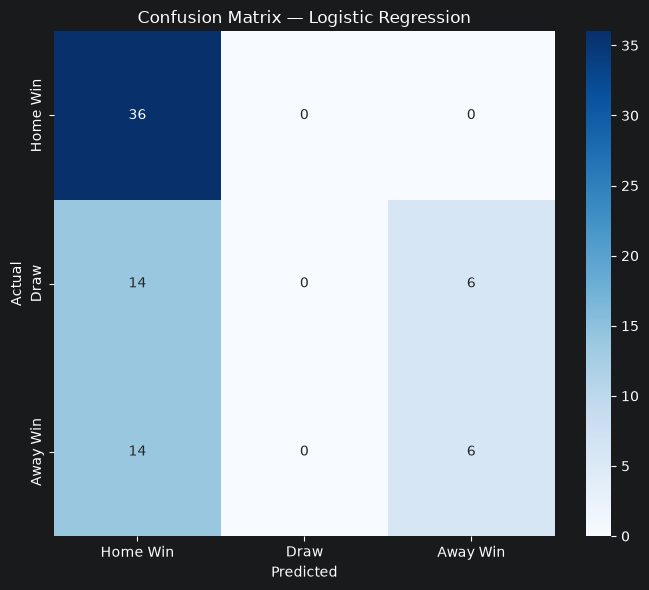

In [19]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Home Win", "Draw", "Away Win"],
    yticklabels=["Home Win", "Draw", "Away Win"]
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## 10. Baseline vs Logistic Regression

We now compare the simple baseline against our first actual machine learning model.

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy
    ]
})

comparison

,Model,Accuracy
0,Dummy Baseline,0.473684
1,Logistic Regression,0.552632


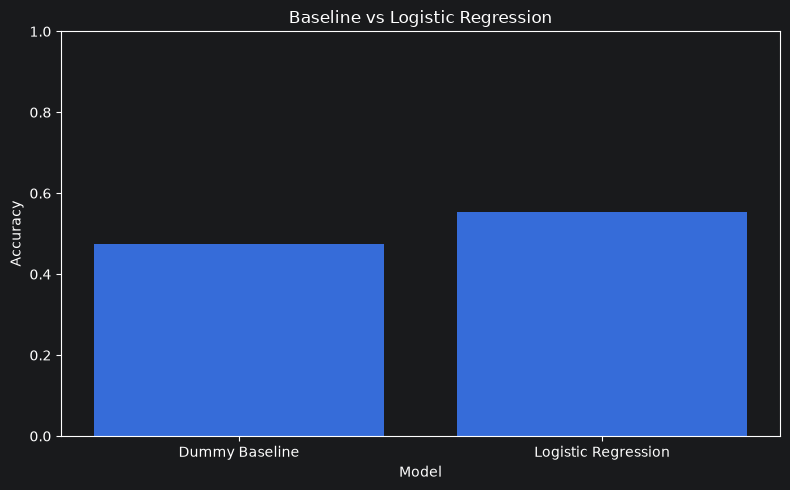

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Baseline vs Logistic Regression")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 11. Initial Interpretation

At this stage we should ask:

1. Did Logistic Regression beat the baseline?
2. Which class is hardest to predict?
3. Is the model particularly weak at predicting draws?
4. Is the dataset imbalanced?
5. Is the performance good enough to justify trying more models?

We should not judge the final project based on this first model.

This is our initial baseline for comparison with more appropriate models.

In [22]:
print("===== MODEL SUMMARY =====")

print(
    "Baseline accuracy:",
    round(baseline_accuracy, 4)
)

print(
    "Logistic Regression accuracy:",
    round(logistic_accuracy, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

===== MODEL SUMMARY =====
Baseline accuracy: 0.4737
Logistic Regression accuracy: 0.5526

Classification Report:
              precision    recall  f1-score   support

           A       0.50      0.30      0.38        20
           D       0.00      0.00      0.00        20
           H       0.56      1.00      0.72        36

    accuracy                           0.55        76
   macro avg       0.35      0.43      0.36        76
weighted avg       0.40      0.55      0.44        76



C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\LENOVO\PycharmProjects\DataScience_Football\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

# Viva Check

Try answering these yourself before looking anything up:

1. Why is predicting `FTR` a classification problem?

2. Why did we avoid using `FTHG`, `FTAG`, `HS`, `AS`, etc. as features?

3. Why did we use chronological splitting instead of a random train/test split?

4. What is a baseline model?

5. Why is Logistic Regression useful as a first ML model?

6. What is the difference between precision and recall?

7. What does a confusion matrix tell us?

8. Why can accuracy be misleading when classes are imbalanced?